## Phase1 : Basics SVD Martix

In [7]:
import numpy as np
import matplotlib.pyplot as plt
A = np.array([
    [3, 1, 1],
    [-1, 3, 1]
], dtype=float)

print("Original Matrix A:")
print(A)
print("Shape:", A.shape)

U, S, Vt = np.linalg.svd(A, full_matrices=True)

print("\nU matrix (left singular vectors):")
print(U)

print("\nSingular values (S):")
print(S)

print("\nVt matrix (right singular vectors):")
print(Vt)
Sigma = np.zeros(A.shape)
Sigma[:min(A.shape), :min(A.shape)] = np.diag(S)

# Reconstruct
A_reconstructed = U @ Sigma @ Vt

print("\nReconstructed A:")
print(A_reconstructed)

print("\nReconstruction error:")
print(np.allclose(A, A_reconstructed)) # Should print True

Original Matrix A:
[[ 3.  1.  1.]
 [-1.  3.  1.]]
Shape: (2, 3)

U matrix (left singular vectors):
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Singular values (S):
[3.46410162 3.16227766]

Vt matrix (right singular vectors):
[[-4.08248290e-01 -8.16496581e-01 -4.08248290e-01]
 [-8.94427191e-01  4.47213595e-01  5.26260748e-16]
 [-1.82574186e-01 -3.65148372e-01  9.12870929e-01]]

Reconstructed A:
[[ 3.  1.  1.]
 [-1.  3.  1.]]

Reconstruction error:
True


## Phase 2 — Apply SVD to a Real Image

Image shape: (512, 512)


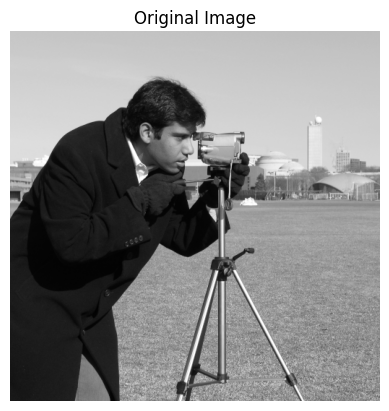

In [8]:
from skimage import data
import matplotlib.pyplot as plt
image = data.camera() # Built-in grayscale image
print("Image shape:", image.shape)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [9]:
image_float = image.astype(float)

U, S, Vt = np.linalg.svd(image_float, full_matrices=False)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("\nTop 10 singular values:")
print(S[:10])

U shape: (512, 512)
S shape: (512,)
Vt shape: (512, 512)

Top 10 singular values:
[70966.03483872 17054.5910748  13314.90060259  8837.41448185
  5874.62439417  4350.94629303  3729.07962631  3474.87862817
  3411.84114657  3030.67422603]


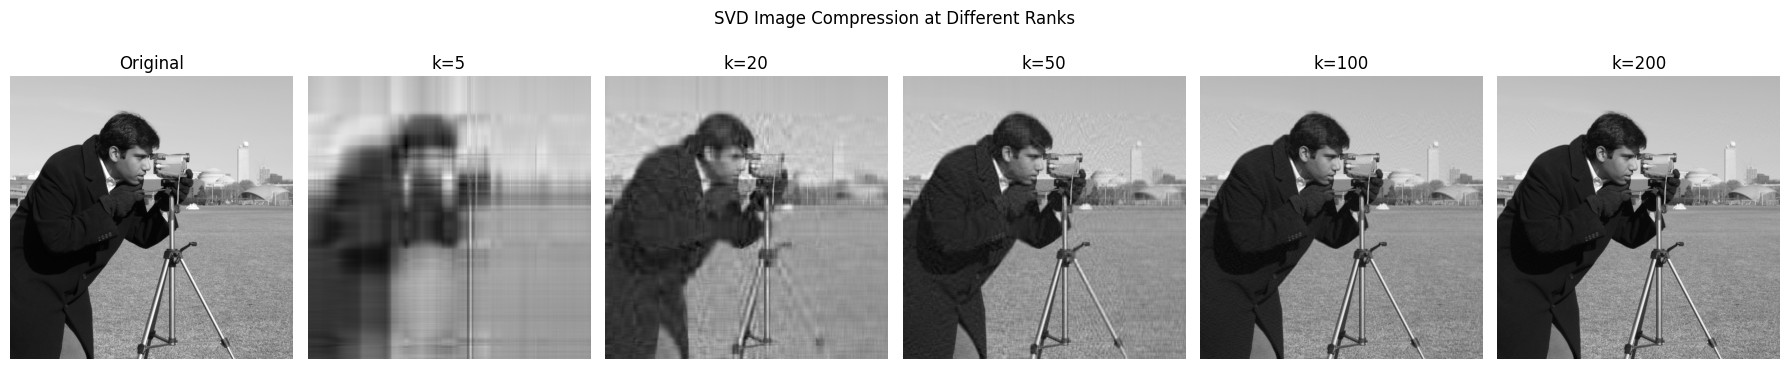

In [10]:

def compress_image(U, S, Vt, k):
    # Keep only top k components
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    return U_k @ S_k @ Vt_k

# Try different values of k
k_values = [5, 20, 50, 100, 200]

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(18, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(k_values):
    compressed = compress_image(U, S, Vt, k)
    axes[i+1].imshow(compressed, cmap='gray')
    axes[i+1].set_title(f"k={k}")
    axes[i+1].axis('off')

plt.suptitle("SVD Image Compression at Different Ranks")
plt.tight_layout()
plt.show()

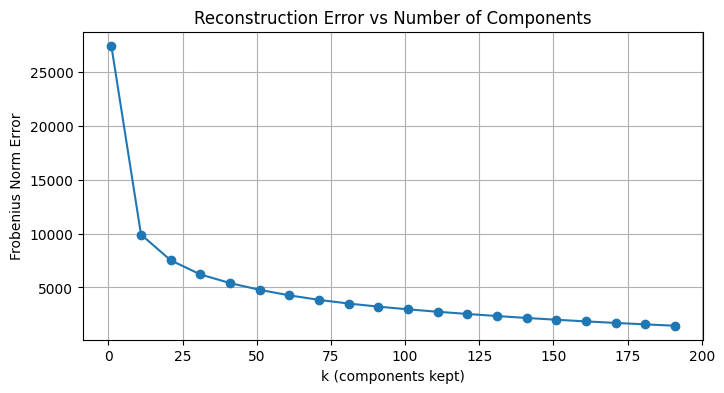

In [11]:
# STEP 5.2: Compute reconstruction error vs k
# ----------------------------
errors = []
k_range = range(1, 201, 10)

for k in k_range:
    compressed = compress_image(U, S, Vt, k)
    error = np.linalg.norm(image_float - compressed, 'fro') # Frobenius norm
    errors.append(error)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), errors, marker='o')
plt.title("Reconstruction Error vs Number of Components")
plt.xlabel("k (components kept)")
plt.ylabel("Frobenius Norm Error")
plt.grid(True)
plt.show()